# **Planteamiento de Problema**

El siguiente proyecto tiene como objetivo generar un modelo para la predicción de precios de viviendas. Para el desarrollo se utilizó una base de datos de la plataforma Kaggle, la cual se la puede encontrar en el siguiente enlace:
https://www.kaggle.com/datasets/debayank2024/house-price-prediction

La base de datos contiene registros históricos de ventas de propiedades, centrados principalmente en el mercado inmobiliario del estado de Washington (incluyendo Seattle, Bellevue, Redmond y sus alrededores)

#**Ambiente de Trabajo**

Se importa las librerias principales para trabajar orientadas al tratamiento de datos, visualización de datos y desarrollo del modelo predictivo.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
from matplotlib.ticker import FuncFormatter
from matplotlib.ticker import MaxNLocator
import seaborn as sns

#librerías para modelos de predicción
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (
    GridSearchCV,
    RandomizedSearchCV,
    KFold
)
from scipy.stats import randint
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#**Carga de Datos y Vistazo general**

Se extrae la base de datos de nuestra fuente.

In [2]:
import kagglehub

path = kagglehub.dataset_download("debayank2024/house-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'house-price-prediction' dataset.
Path to dataset files: /kaggle/input/house-price-prediction


In [3]:
import os

file_names = os.listdir(path)
print(f"Files in the dataset directory: {file_names}")

Files in the dataset directory: ['modified_data.csv']


In [4]:
file_path = os.path.join(path, file_names[0])

df = pd.read_csv(file_path)

df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,233.58
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,653.15
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,177.20
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,210.00
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,283.51


### **Variables de la base de datos.**

* **date:** La fecha específica en que se registró la transacción inmobiliaria.
* **price:** Precio final de venta del inmueble en USD (Variable objetivo)
* **bedrooms:** El número total de dormitorios en la propiedad
* **bathrooms:** Numero total de baños. Los valores fraccionarios (p. ej., 1,5, 2,25) indican baños parciales
* **sqft_living:** La superficie total interior del espacio habitable en pies2
* **sqft_lot:** La superficie total en pies cuadrados del terreno o lote en el que se encuentra la propiedad.
* **floors:** El número de pisos o niveles de la propiedad
* **waterfront:** Un indicador binario (1 o 0) que indica si la propiedad tiene acceso al mar.
* **view:** A rated index (0 to 4) indicating the overall quality of the property's view
* **condition:** Un índice de calificación (de 1 a 5) que indica el estado estructural y estético general de la propiedad.
* **sqft_above:** Se refiere a toda el área habitable y terminada de una casa ubicada completamente por encima del nivel del suelo.
* **sqft_basement:** pies cuadrados totales de la planta baja o sótano de una propiedad.
* **yr_built:** año de construcción de la propiedad
* **yr_renovated:** año de renovación de la propiedad
* **street:** calle donde se ubica
* **city:** ciudad donde se ubica
* **statezip:** código postal estatal
* **price_per_sqft:** precio por pie cuadrado


###**Pre-visualización general de los datos**

Se realiza un primer vistazo de la base de datos. Se revisan aspectos generales como el número de registros y variables, los tipos de datos y una muestra inicial de las observaciones, con el objetivo de obtener una visión preliminar de la información disponible

In [5]:
#Se revisa la información general de los datos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   date            4600 non-null   object 
 1   price           4600 non-null   float64
 2   bedrooms        4600 non-null   float64
 3   bathrooms       4600 non-null   float64
 4   sqft_living     4600 non-null   int64  
 5   sqft_lot        4600 non-null   int64  
 6   floors          4600 non-null   float64
 7   waterfront      4600 non-null   int64  
 8   view            4600 non-null   int64  
 9   condition       4600 non-null   int64  
 10  sqft_above      4600 non-null   int64  
 11  sqft_basement   4600 non-null   int64  
 12  yr_built        4600 non-null   int64  
 13  yr_renovated    4600 non-null   int64  
 14  street          4600 non-null   object 
 15  city            4600 non-null   object 
 16  statezip        4600 non-null   object 
 17  price_per_sqft  4600 non-null   f

In [6]:
# Se analiza los estadísticos
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,price_per_sqft
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261,265.876209
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536,357.503362
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000,180.817500
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000,243.855000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000,314.840000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000,22533.900000


In [7]:
#análisis de duplicados

df.duplicated().sum()

np.int64(0)

In [8]:
# análisis de valores únicos
df.nunique()

,0
date,70
price,1741
bedrooms,10
bathrooms,26
sqft_living,566
sqft_lot,3113
floors,6
waterfront,2
view,5
condition,5


**Observaciones**

* No hay presencia de valores nulos ni duplicados
* Se puede corregir el tipo de dato en variables como *date*, *waterfront*, *view*, *condition*.
* El análisis estadístico muestra un indicio de posible presencia de outliers, considerando principalmente la variable *price* que es la variable objetivo. También se observa que hay viviendas cuyo precio es 0, lo cual requiere indagarse más a profundidad.

# **Limpieza y Tratamiento de Datos**



In [9]:
#Tranformo el tipo de datos en las variables que lo requieran para que estén mejor estructuradas.

df['waterfront'] = df['waterfront'].astype('category')
df['view'] = df['view'].astype('category')
df['condition'] = df['condition'].astype('category')


df['date'] = pd.to_datetime(df['date'])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4600 non-null   datetime64[ns]
 1   price           4600 non-null   float64       
 2   bedrooms        4600 non-null   float64       
 3   bathrooms       4600 non-null   float64       
 4   sqft_living     4600 non-null   int64         
 5   sqft_lot        4600 non-null   int64         
 6   floors          4600 non-null   float64       
 7   waterfront      4600 non-null   category      
 8   view            4600 non-null   category      
 9   condition       4600 non-null   category      
 10  sqft_above      4600 non-null   int64         
 11  sqft_basement   4600 non-null   int64         
 12  yr_built        4600 non-null   int64         
 13  yr_renovated    4600 non-null   int64         
 14  street          4600 non-null   object        
 15  city

In [10]:
# ¿Cúantos registros de viviendas con precio 0 hay?
num_zeros = (df['price'] == 0).sum()
print(f"Hay {num_zeros} registros donde el precio es 0.")

Hay 49 registros donde el precio es 0.


**¿Qué implica que existan registros donde el precio de vivienda sea 0?**

En este caso se los va a considerar como registros de no transacciones, es decir que no hubo venta por lo cual no hubo valoración. Y siendo ese el caso, son registros que no sirven para éste análisis; incluso pueden generar sesgos, por lo que se requiere eliminarlos.


In [11]:
# se elimina los registros con precio 0
df_limpio = df[df['price'] != 0]
df_limpio.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4551 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4551 non-null   datetime64[ns]
 1   price           4551 non-null   float64       
 2   bedrooms        4551 non-null   float64       
 3   bathrooms       4551 non-null   float64       
 4   sqft_living     4551 non-null   int64         
 5   sqft_lot        4551 non-null   int64         
 6   floors          4551 non-null   float64       
 7   waterfront      4551 non-null   category      
 8   view            4551 non-null   category      
 9   condition       4551 non-null   category      
 10  sqft_above      4551 non-null   int64         
 11  sqft_basement   4551 non-null   int64         
 12  yr_built        4551 non-null   int64         
 13  yr_renovated    4551 non-null   int64         
 14  street          4551 non-null   object        
 15  city     

# **Análisis Exploratorio de Datos**

### **Análisis Variable objetivo *Price***

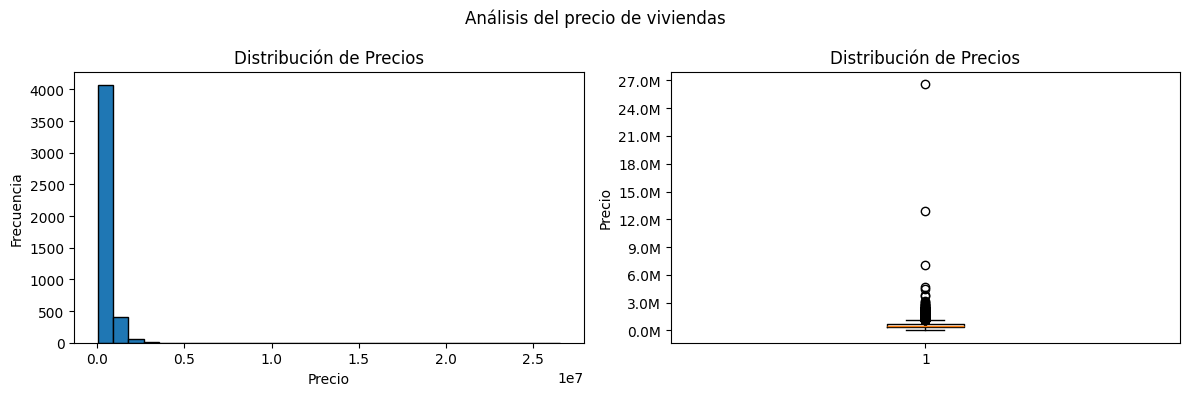

In [12]:
fig, axes = plt.subplots(1,2, figsize=(12,4))

fig.suptitle('Análisis del precio de viviendas')

axes[0].hist(df_limpio['price'], bins=30, edgecolor='black')
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Precios')


axes[1].boxplot(df_limpio['price'])
axes[1].set_title('Distribución de Precios')
axes[1].set_ylabel('Precio')
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.tight_layout()
plt.show()


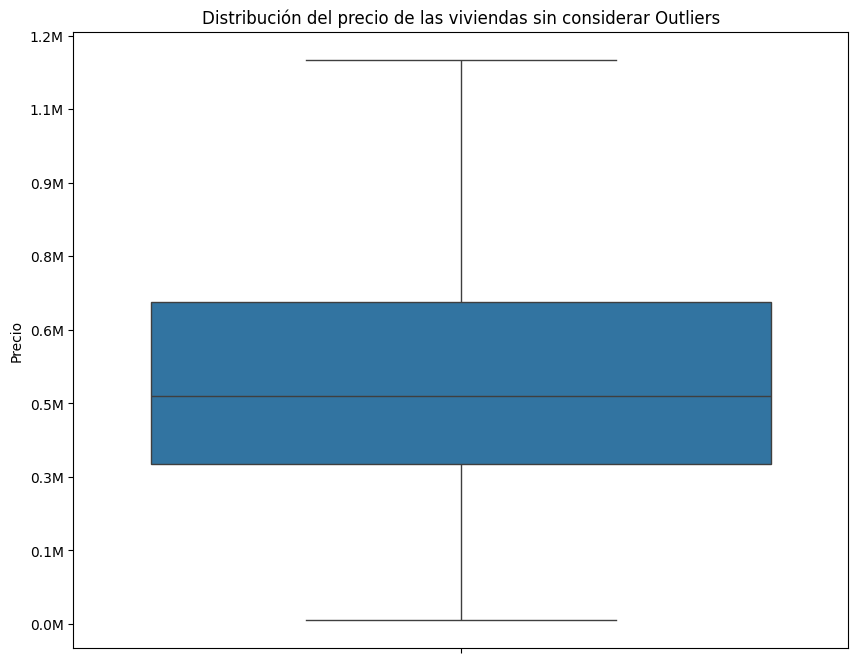

In [13]:
plt.figure(figsize=(10,8))

sns.boxplot(data=df_limpio, y='price', showfliers= False )

plt.title('Distribución del precio de las viviendas sin considerar Outliers')
plt.ylabel('Precio')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.show()

Se observa valores atípicos en los precios de la vivienda, de hecho, algunos valores se excenden con notable diferencia en relación al resto. El precio de la mayoria de viviendas se distribuye alrededor de los 500k, pero hay dos registros que exceden los 10 Millones.


In [14]:
#analizando outliers según el precio
df_limpio[df_limpio['price'] > 1e7]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4346,2014-06-23,12899000.0,3.0,2.5,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,5889.95
4350,2014-07-03,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,22533.90


In [15]:
#consideres un precio por pie2 superior a los $2000
df_limpio[df_limpio['price_per_sqft']>2000]

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,price_per_sqft
4346,2014-06-23,12899000.0,3.0,2.5,2190,11394,1.0,0,0,3,1550,640,1956,2001,5426 40th Ave W,Seattle,WA 98199,5889.95
4350,2014-07-03,26590000.0,3.0,2.0,1180,7793,1.0,0,0,4,1180,0,1992,0,12005 SE 219th Ct,Kent,WA 98031,22533.90


Los dos registros analizados siguen siendo los únicos. Superan con una notable diferencia el precio por pie2 de las demás casas y esto ratifica el hecho de que estos registros también sean outliers.

Ante esto se considera eliminar estos registros ahora para que no afecten el análisis exploratorio y visual de los datos; y para que tampoco integren el modelo de predicción.

In [16]:
df_limpio2 = df_limpio[df_limpio['price_per_sqft']<2000]
df_limpio2.shape

(4549, 18)

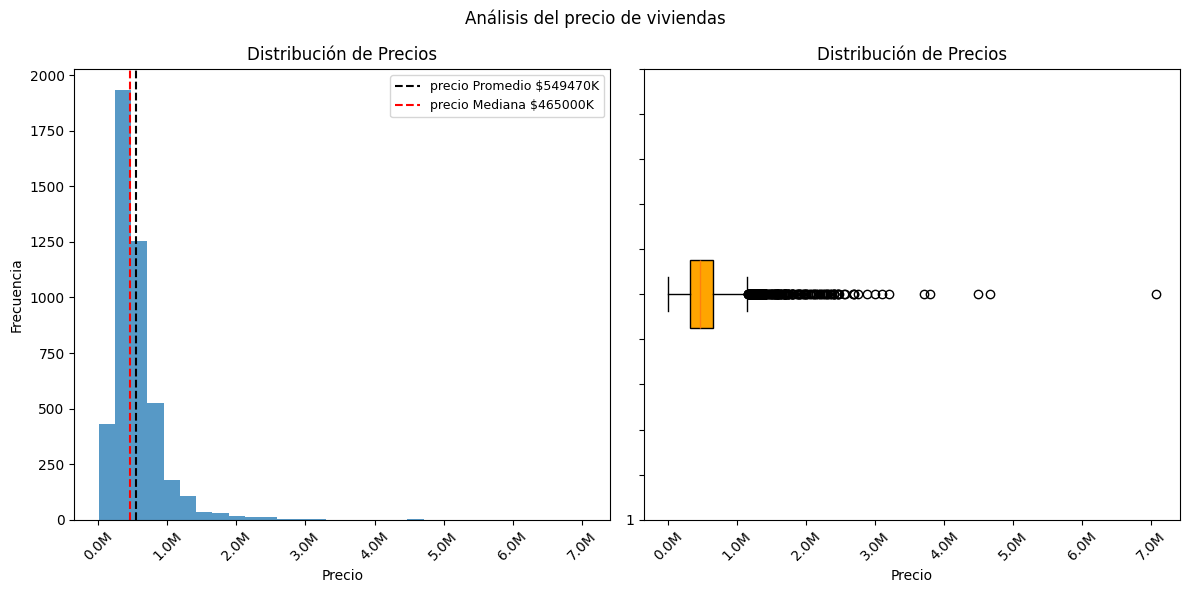

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,6))

fig.suptitle('Análisis del precio de viviendas')


axes[0].hist(df_limpio2['price'], bins=30, alpha=0.75)
axes[0].axvline(df_limpio2['price'].mean(), linestyle='--', color='black', label=f"precio Promedio ${df_limpio2['price'].mean():.0f}K")
axes[0].axvline(df_limpio2['price'].median(), linestyle='--', color='red', label=f"precio Mediana ${df_limpio2['price'].median():.0f}K")
axes[0].legend(fontsize=9)
axes[0].set_xlabel('Precio')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Precios')
axes[0].xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
axes[0].yaxis.set_major_locator(MaxNLocator(nbins=10))
axes[0].tick_params(axis='x', rotation=45)


axes[1].boxplot(df_limpio2["price"], patch_artist=True,
    boxprops=dict(facecolor='orange'), vert=False)
axes[1].set_title('Distribución de Precios')
axes[1].set_xlabel('Precio')
axes[1].xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
axes[1].yaxis.set_major_locator(MaxNLocator(nbins=10))
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

* la media es aproximadamente superior en 100k a la mediana debido a que los precios elevados en varias viviendas influyen en esta métrica estadística.

### **Análisis segun los cuartos (*Bedrooms*) y baños (*Bathrooms*)**

In [18]:
df_limpio2.groupby('bedrooms')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

,count,mean,median
bedrooms,,,
3.0,2023,471266.76,425000.0
4.0,1512,643100.36,575000.0
2.0,561,395112.31,370000.0
5.0,338,804365.84,599000.0
6.0,59,845070.06,670000.0
1.0,37,281483.78,275000.0
7.0,14,1049428.57,711500.0
0.0,2,1195324.00,1195324.0
8.0,2,1155000.00,1155000.0


In [19]:
df_limpio2.groupby('bathrooms')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

,count,mean,median
bathrooms,,,
2.50,1183,564706.25,525000.00
1.00,736,335784.14,307500.00
1.75,628,460281.41,434000.00
2.00,424,467873.47,437250.00
2.25,413,544982.48,478000.00
1.50,287,416773.12,368000.00
2.75,270,657722.89,617210.00
3.00,164,718470.23,601250.00
3.50,159,920040.40,828950.00


* Casi no hay registros para viviendas de 0, 8 y 9 cuartos.

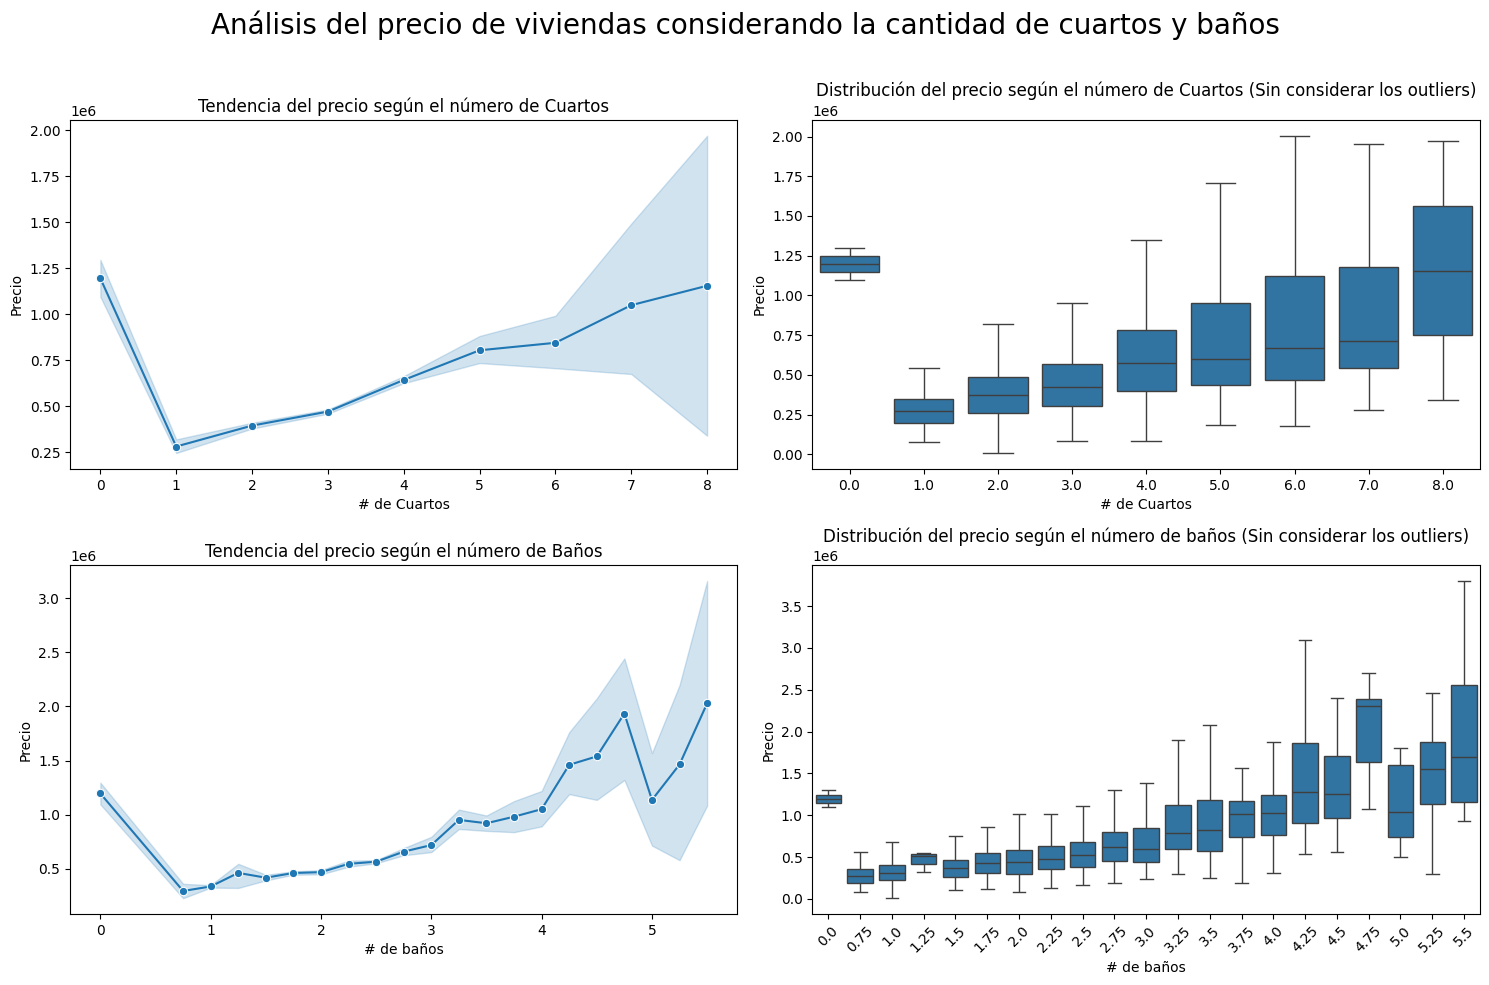

In [20]:
# análisis del precio según los cuartos y según los baños

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

fig.suptitle('Análisis del precio de viviendas considerando la cantidad de cuartos y baños\n',size=20)

sns.lineplot(
    data=df_limpio2.groupby('bedrooms').filter(lambda x: len(x) >= 2), #Agrupa temporalmente las filas por cuartos, evalúa cada grupo y devuelve las filas originales de aquellos grupos que cumplen la condición.
    x='bedrooms',
    y='price',
    marker='o',
    ax=axes[0,0]
)
axes[0,0].set_title('Tendencia del precio según el número de Cuartos')
axes[0,0].set_xlabel('# de Cuartos');
axes[0,0].set_ylabel('Precio')

#--------------------------------------------------------------------------------

sns.boxplot(
    data=df_limpio2.groupby('bedrooms').filter(lambda x: len(x) >= 2),
    x='bedrooms',
    y='price',
    showfliers=False, # no se considera los outliers
    ax=axes[0,1]
)
axes[0,1].set_title('Distribución del precio según el número de Cuartos (Sin considerar los outliers)')
axes[0,1].set_xlabel('# de Cuartos'),
axes[0,1].set_ylabel('Precio')

#--------------------------------------------------------------------------------
sns.lineplot(
    data=df_limpio2.groupby('bathrooms').filter(lambda x: len(x) > 1),
    x='bathrooms',
    y='price',
    marker='o',
    ax=axes[1,0]
)

axes[1,0].set_title('Tendencia del precio según el número de Baños')
axes[1,0].set_xlabel('# de baños'),
axes[1,0].set_ylabel('Precio')



#--------------------------------------------------------------------------------

sns.boxplot(
    data=df_limpio2.groupby('bathrooms').filter(lambda x: len(x) > 1),
    x='bathrooms',
    y='price',
    showfliers= False, # no se considera los outliers
    ax=axes[1,1]
)
axes[1,1].set_title('Distribución del precio según el número de baños (Sin considerar los outliers)')
axes[1,1].set_xlabel('# de baños'),
axes[1,1].set_ylabel('Precio')
axes[1,1].tick_params(axis='x', rotation=45)


fig.tight_layout()

plt.show()

* El número de cuartos y baños es importante en la definición del precio, con una ligera tendencia creciente en el precio al aumentar la cantidad de cuartos o baños
* No hay muchos registros de viviendas con más de 5 baños o de 7 cuartos.
* Se observa la presencia de casas que no poseen cuartos o no poseen baños. Esto parece ilógico o puede implicar otro tipo de vivienda que está dentro del dataset. Sin embargo también se observa que estas viviendas sin cuartos o baños presentan un precio elevado en comparación a otras viviendas que si los presentan, lo que va en contra de la tendencia lógica. Son pocos los registros, por lo que en este caso se considera ideal eliminarlos del dataset.

In [21]:
#veamos cuantos datos representan.
cuartos_banos_0 = df_limpio2[(df_limpio2['bedrooms']==0) | (df_limpio2['bathrooms']==0)]
print(f"el número de registros de viviendas con 0 cuartos o 0 baños es: {cuartos_banos_0.shape[0]}")


el número de registros de viviendas con 0 cuartos o 0 baños es: 2


In [22]:
print(f'dimensión de la tabla previo a eliminación de registros {df_limpio2.shape}')
df_limpio2 = df_limpio2[(df_limpio2['bedrooms']!=0) | (df_limpio2['bathrooms']!=0)]
print(f'dimensión de la tabla despues de la eliminación de registros {df_limpio2.shape}')

dimensión de la tabla previo a eliminación de registros (4549, 18)
dimensión de la tabla despues de la eliminación de registros (4547, 18)


### **Análisis segun el número de pisos (*floors*)**

In [23]:
df_limpio2.groupby('floors')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

,count,mean,median
floors,,,
1.0,2149,444222.83,395000.0
2.0,1790,654863.47,556500.0
1.5,439,585283.73,536000.0
3.0,127,570615.52,480000.0
2.5,41,983863.39,831500.0
3.5,1,563500.00,563500.0


Text(0, 0.5, 'Precio')

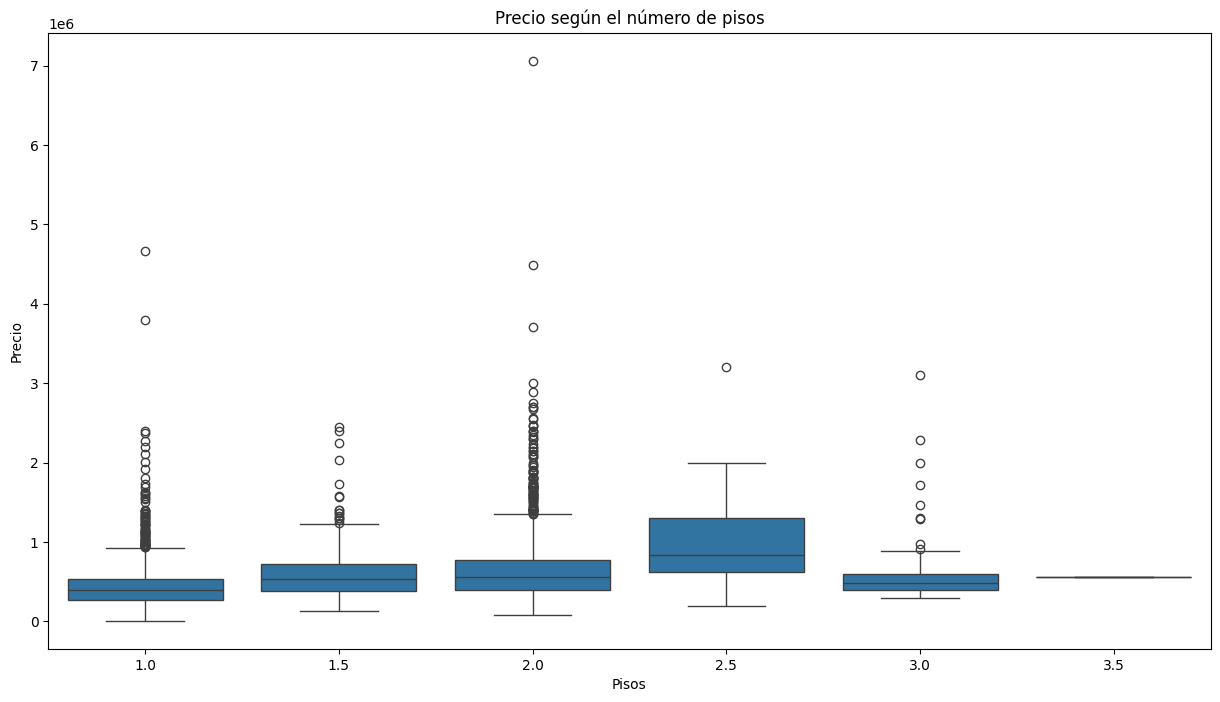

In [24]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_limpio2, x='floors', y = 'price', showfliers= True)
plt.title('Precio según el número de pisos')
plt.xlabel('Pisos')
plt.ylabel('Precio')

* El precio de las viviendas no presenta una tendencia creciente y consistente a medida que aumenta el número de pisos. Además, se observa la presencia de numerosos valores atípicos en varias categorías. Por lo tanto, el número de pisos, considerado de forma aislada, no muestra una relación clara y consistente con el precio. No obstante, esto no implica que la variable carezca de capacidad predictiva, ya que su efecto podría estar condicionado por otras características de la vivienda, como su superficie, ubicación o calidad.

### **Análisis según la vista al mar (*waterfront*)**

In [25]:
df_limpio2.groupby('waterfront')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

/tmp/ipykernel_60792/3580406114.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpio2.groupby('waterfront')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)


,count,mean,median
waterfront,,,
0,4517,542228.60,463000.0
1,30,1596783.33,1072500.0


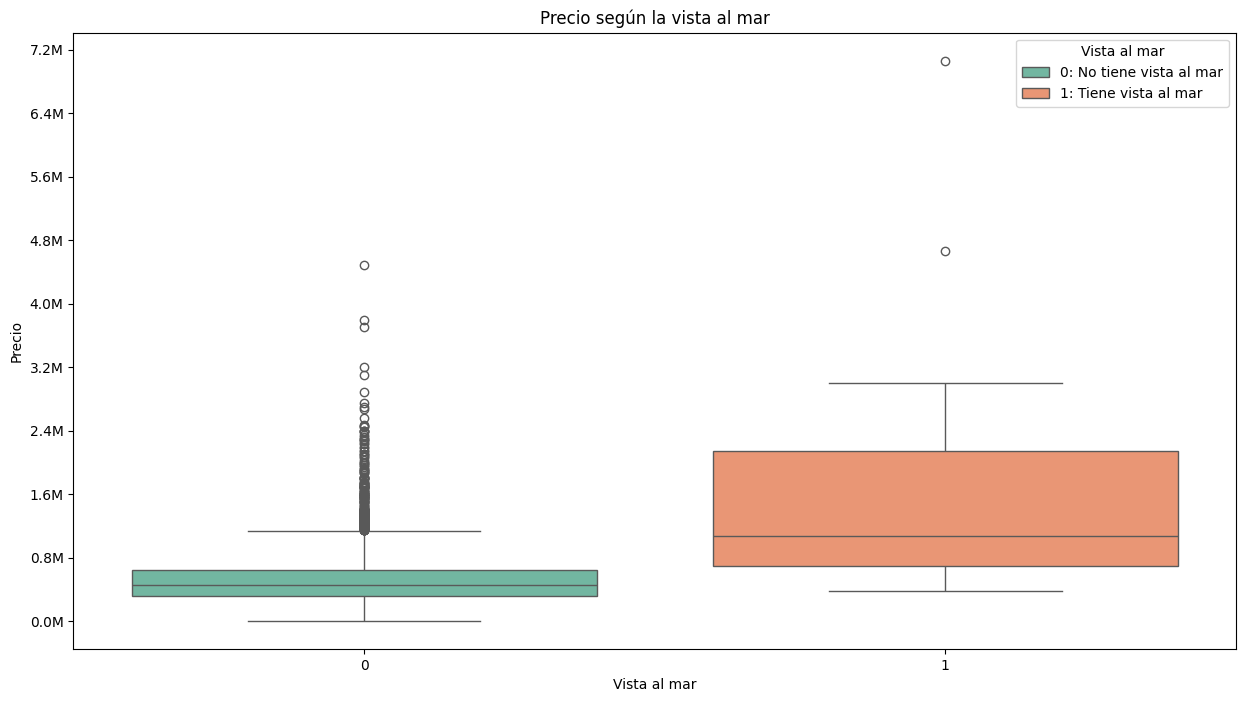

In [26]:
#analizando la vista al mar
plt.figure(figsize=(15,8))
sns.boxplot(data=df_limpio2,
    x='waterfront',
    y = 'price',
    hue='waterfront',
    palette='Set2',
    legend=True)
plt.legend(title='Vista al mar',
           labels=['0: No tiene vista al mar', '1: Tiene vista al mar'])
plt.title('Precio según la vista al mar')
plt.xlabel('Vista al mar')
plt.ylabel('Precio')
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))

* Las viviendas con vista al mar representan una muestra reducida (n = 30), pero registran precios sensiblemente más altos y con mayor dispersión en compaación con aquellas que no tienen esta característica.

* Aunque la mayoria de registros de viviendas sin vista al mar se concentran en rangos de precios inferiores a los que tienen vista, existen un número considerable de atípicos cuyo precio se asimila o supera las viviendas con vista al mar. Posiblemente debido a otros factores como tamaño, ubicación entre otros.


### **Análisis según el índice de calificación de Vista y Condición de la vivienda (*View* y *Condition*)**

In [27]:
# analisis del precio según la calificación de vista
df_limpio2.groupby('view')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

/tmp/ipykernel_60792/2184395089.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpio2.groupby('view')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)


,count,mean,median
view,,,
0,4100,505719.72,445000.0
2,200,823683.67,662975.0
3,115,1006887.58,900000.0
1,69,867010.97,719000.0
4,63,1322963.00,1149000.0


/tmp/ipykernel_60792/3887146487.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vista_mediana = df_limpio2.groupby('view')['price'].median()
/tmp/ipykernel_60792/3887146487.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  vista_media = df_limpio2.groupby('view')['price'].mean()


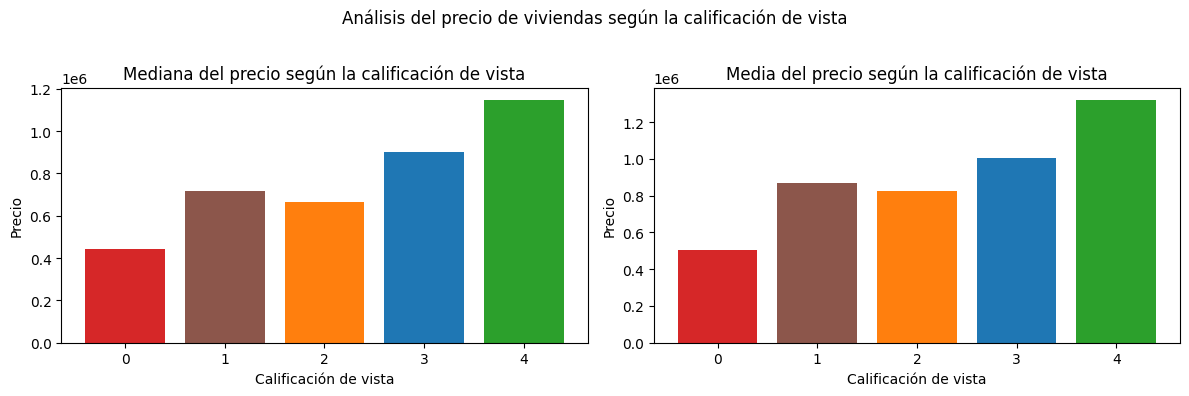

In [28]:
# genero una gráfica para analizar la media y otra la mediana
fig, ax = plt.subplots(1,2, figsize=(12,4))

fig.suptitle('Análisis del precio de viviendas según la calificación de vista')

vista_mediana = df_limpio2.groupby('view')['price'].median()
vista_media = df_limpio2.groupby('view')['price'].mean()
bar_colors = ['tab:red', 'tab:brown', 'tab:orange', 'tab:blue', 'tab:green']

ax[0].bar(vista_mediana.index, vista_mediana.values, color = bar_colors)
ax[0].set_title('Mediana del precio según la calificación de vista')
ax[0].set_xlabel('Calificación de vista')
ax[0].set_ylabel('Precio')

ax[1].bar(vista_media.index, vista_media.values, color = bar_colors)
ax[1].set_title('Media del precio según la calificación de vista')
ax[1].set_xlabel('Calificación de vista')
ax[1].set_ylabel('Precio')

plt.tight_layout()
plt.show()

In [29]:
df_limpio2.groupby('condition')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)

/tmp/ipykernel_60792/542085105.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_limpio2.groupby('condition')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)


,count,mean,median
condition,,,
3,2848,549958.20,465625.0
4,1237,518622.80,440000.0
5,425,652030.53,558000.0
2,31,334837.42,250000.0
1,6,306633.33,310000.0


Text(0, 0.5, 'Precio')

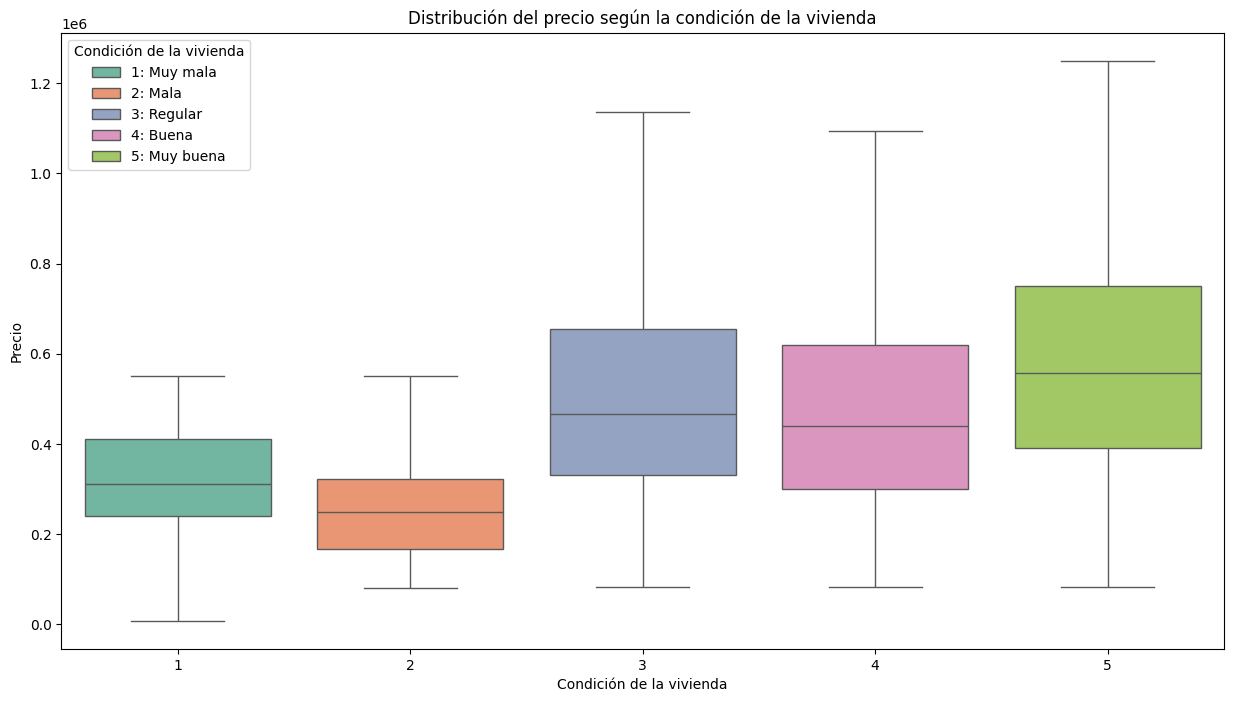

In [30]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df_limpio2,
    x='condition',
    y = 'price',
    hue='condition',
    palette='Set2',
    showfliers=False,
    legend=True)
plt.legend(title='Condición de la vivienda',
           labels=['1: Muy mala', '2: Mala', '3: Regular', '4: Buena', '5: Muy buena'])
plt.title('Distribución del precio según la condición de la vivienda')
plt.xlabel('Condición de la vivienda')
plt.ylabel('Precio')

* Se observa un crecimiento casi lineal del precio a medida que la calificación de "vista" de las viviendas es más alto.

* Se observa también un crecimiento del precio a medida que la calificación según la "condición" de la vivienda tiene mejor valoración. Aunque este crecimiento no es tan pronunciado cuando la vivienda tiene una valoración de *regular* a *muy buena*

En general, considerando las calificaciones y su rango de distribución, se puede decir que los factores analizados poseen poder explicativo para la predicción del precio, aunque existen otras variables con influencia importante sobre el precio.

En otras palabras, estas variables pueden ayudar al modelo a ajustar mejor la valoración de una vivienda, pero no debería utilizarse como criterio único para establecer el precio.

### **Análisis del Precio según la ubicación (*city*)**

In [31]:
# análisis del precio según la ciudad

df_ciudad = df_limpio2.groupby('city')['price'].agg(['count', 'mean', 'median']).round(2).sort_values('count', ascending=False)
df_ciudad = df_ciudad[df_ciudad['count'] > 10].sort_values('mean', ascending=False)
df_ciudad

,count,mean,median
city,,,
Medina,11,2046559.09,2100000.00
Mercer Island,82,1178637.99,950466.66
Bellevue,281,862255.05,725000.00
Sammamish,171,702985.83,668500.00
Fall City,11,692681.82,563500.00
Newcastle,33,666046.70,602500.00
Redmond,234,664965.78,636500.00
Kirkland,187,651583.59,522000.00
Woodinville,114,614912.08,562450.00


Text(0, 0.5, 'Precio promedio de viviendas\n')

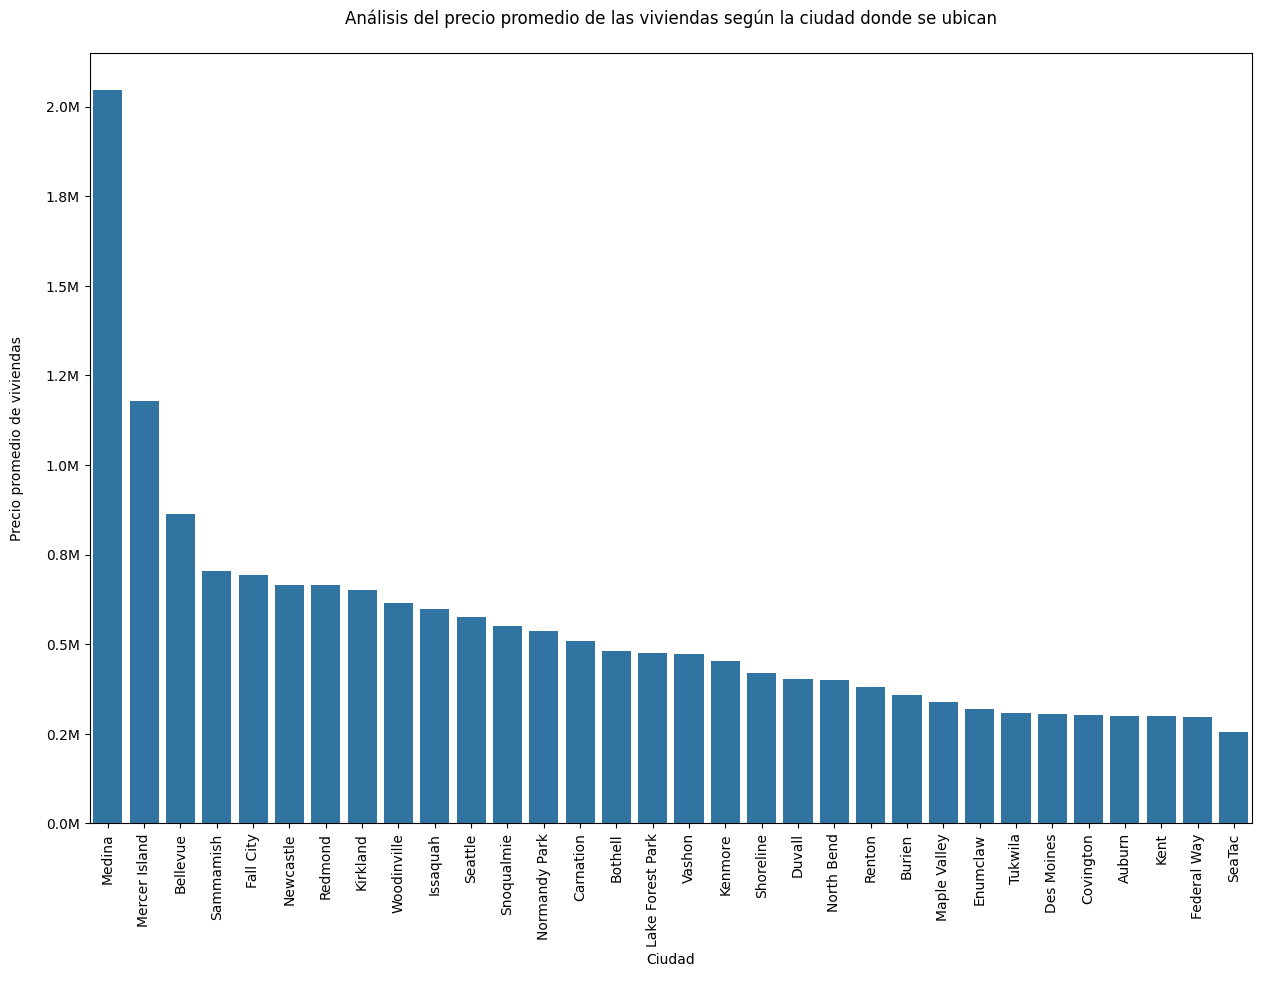

In [32]:
plt.figure(figsize=(15,10))
sns.barplot(
    data=df_ciudad,
    x=df_ciudad.index,
    y='mean'
)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))
plt.xticks(rotation=90)
plt.title('Análisis del precio promedio de las viviendas según la ciudad donde se ubican\n')
plt.xlabel('Ciudad\n')
plt.ylabel('Precio promedio de viviendas\n')

Text(0, 0.5, 'Precio')

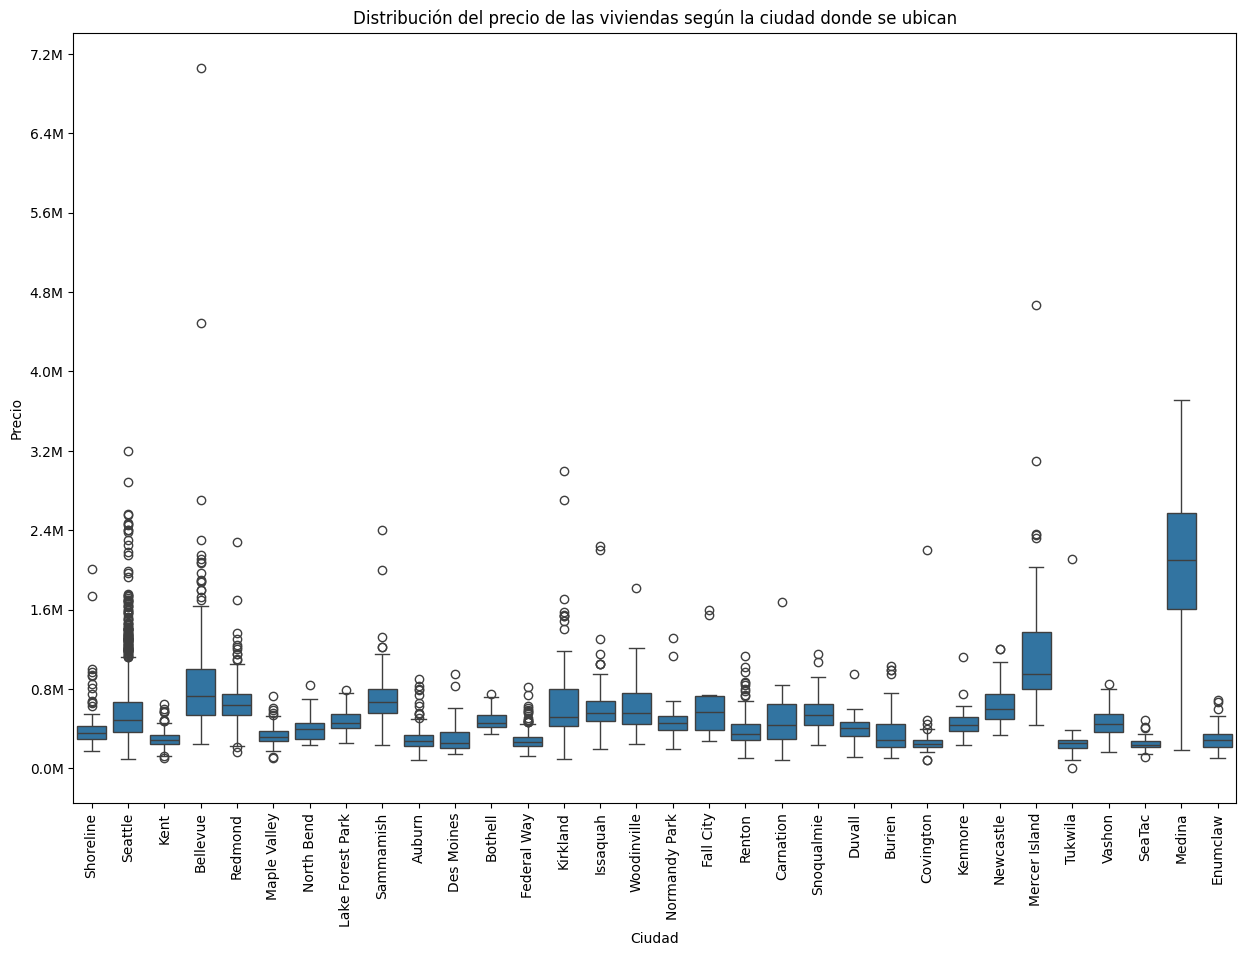

In [33]:
df_ciudades_filtro = df_limpio2.groupby('city').filter(lambda x: len(x) >= 10)

plt.figure(figsize=(15,10))
sns.boxplot(
    data=df_ciudades_filtro,
    x='city',
    y='price')
plt.xticks(rotation=90)
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=10))
plt.title('Distribución del precio de las viviendas según la ciudad donde se ubican')
plt.xlabel('Ciudad')
plt.ylabel('Precio')

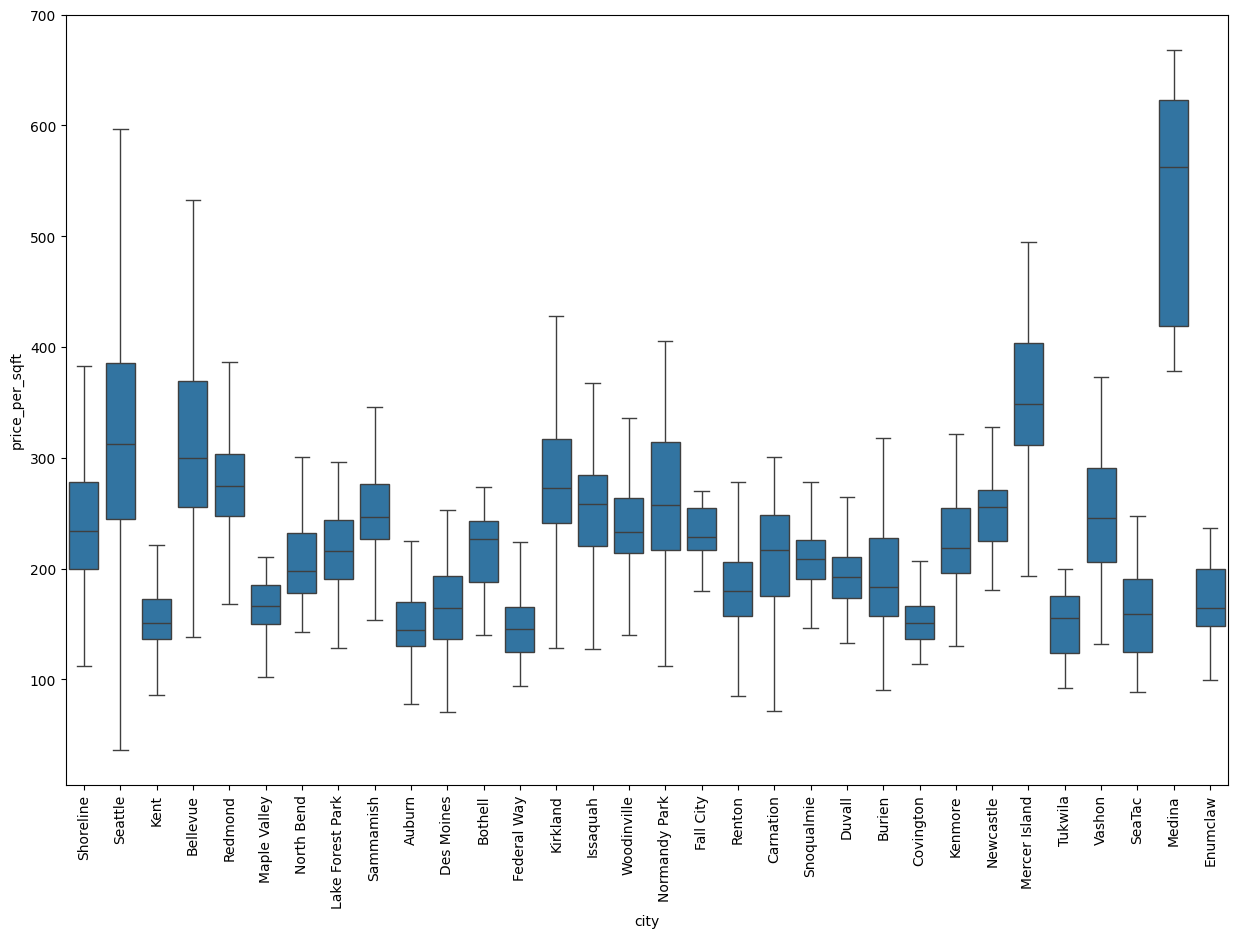

In [34]:
#análisis considerando el precio por pie cuadrado
plt.figure(figsize=(15,10))
sns.boxplot(
    data=df_ciudades_filtro,
    x='city',
    y='price_per_sqft',
    showfliers=False
)
plt.xticks(rotation=90)

plt.show()

* La ubicación de la vivienda según la ciudad de residencia es un parámetro importante al definir el precio. Viviendas que se encuentran en zonas exclusivas llegan a tener un precio 5 veces mayor a los de promedio más bajo.

* El análisis se reafirma más al visualizar la distribución de los precios en las distintas ciudades que conforman el estado.

### **Análisis según el año de construcción y renovación (*yr_built* y *yr_renovated*)**

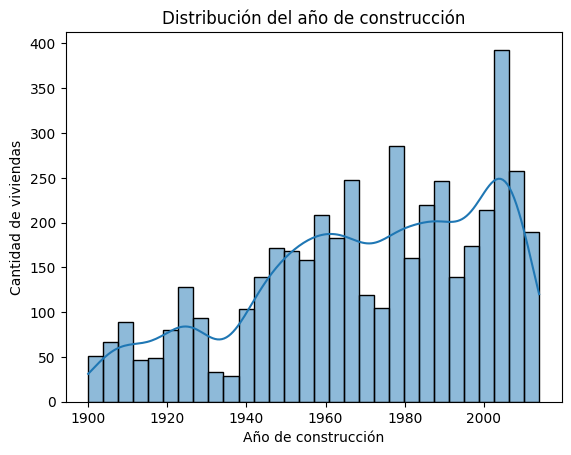

In [35]:
#Se observa la distribución según el año de construcción
sns.histplot(
    data=df_limpio2,
    x='yr_built',
    bins=30,
    kde=True
)

plt.title('Distribución del año de construcción')
plt.xlabel('Año de construcción')
plt.ylabel('Cantidad de viviendas')
plt.show()

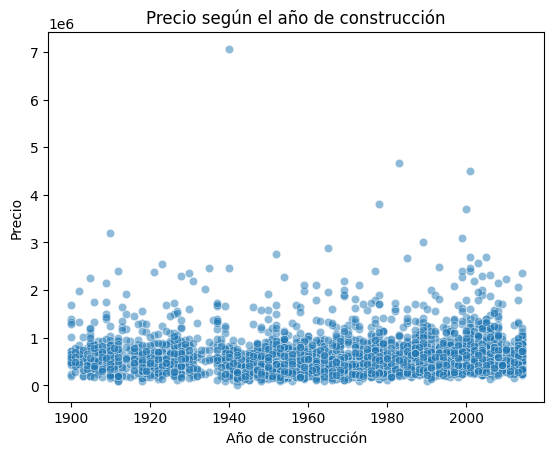

In [36]:
# Se analiza el precio de vivienda según el año de construcción
sns.scatterplot(
    data=df_limpio2,
    x='yr_built',
    y='price',
    alpha=0.5
)

plt.title('Precio según el año de construcción')
plt.xlabel('Año de construcción')
plt.ylabel('Precio')
plt.show()

In [37]:
df_limpio2['yr_renovated'].value_counts().sort_index().head(10)

,count
yr_renovated,
0,2705
1912,33
1913,1
1923,55
1934,6
1945,7
1948,1
1953,1
1954,8


In [38]:
print(f'El porcentaje de viviendas que no han sido renovadas es: {round((df_limpio2[df_limpio2['yr_renovated'] == 0].shape[0] / df_limpio2.shape[0])*100, 2)}%')

El porcentaje de viviendas que no han sido renovadas es: 59.49%


#### Featuring Engineering de estas variables

Se hace un proceso de transformación en las variables *yr_built* y *yr_renovated*.

* Se genera una variable *edad_vivienda* para indicar los años desde que la vivienda se construyó hasta su venta.
* Se genera una variable binaria para indicar si la vivienda fue renovada o no.

In [39]:
#se crea la variable edad de la vivienda

df_limpio2['edad_vivienda'] = df_limpio2['date'].dt.year[0] - df_limpio2['yr_built']

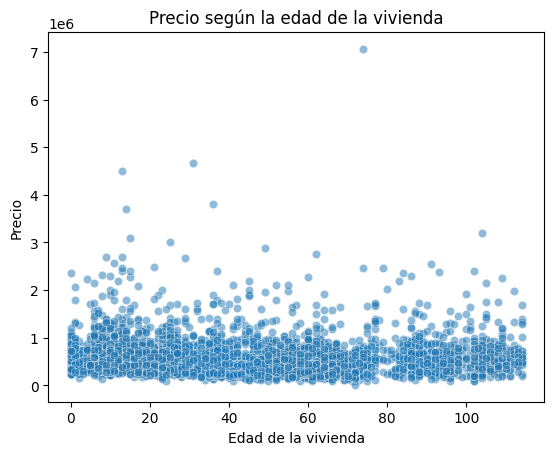

In [40]:
sns.scatterplot(
    data=df_limpio2,
    x='edad_vivienda',
    y='price',
    alpha=0.5
)

plt.title('Precio según la edad de la vivienda')
plt.xlabel('Edad de la vivienda')
plt.ylabel('Precio')
plt.show()


In [41]:
#se crea una variable binaria para validar si una vivienda fue renovada o no

df_limpio2['renovada'] = np.where(df_limpio2['yr_renovated'] > 0, 1, 0)
df_limpio2['renovada'].value_counts()

,count
renovada,
0,2705
1,1842


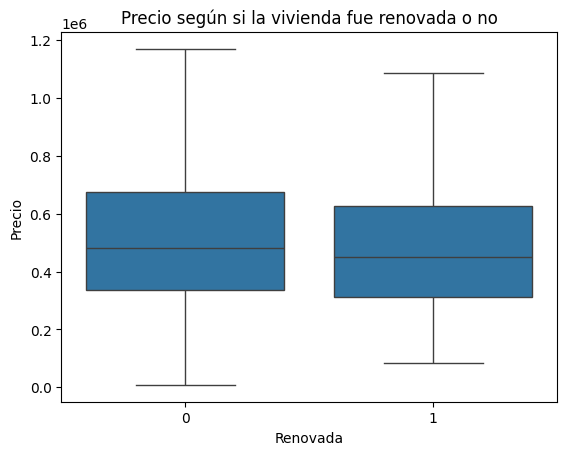

In [42]:
sns.boxplot(
    data=df_limpio2,
    x='renovada',
    y='price',
    showfliers=False
)

plt.title('Precio según si la vivienda fue renovada o no')
plt.xlabel('Renovada')
plt.ylabel('Precio')
plt.show()

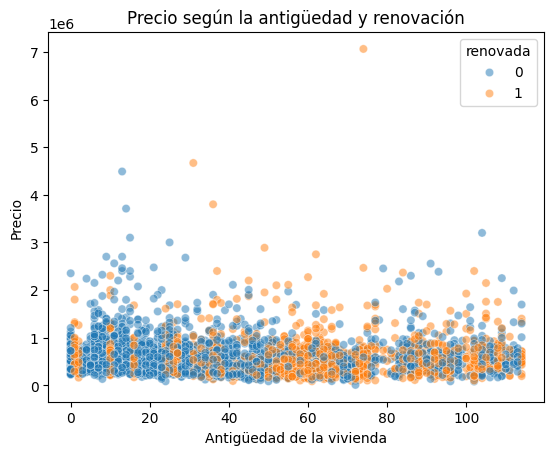

In [43]:
sns.scatterplot(
    data=df_limpio2,
    x='edad_vivienda',
    y='price',
    hue='renovada',
    alpha=0.5
)

plt.title('Precio según la antigüedad y renovación')
plt.xlabel('Antigüedad de la vivienda')
plt.ylabel('Precio')
plt.show()

In [44]:
#Se elimina las variables que ya no se necesitan
df_limpio2.drop(columns=['yr_built', 'yr_renovated'], inplace=True)

* No existe una tendencia clara en el precio de vivienda considerando su año de construcción, por lo que se descarta la suposición de que casas más modernas tienen un mayor precio. Por sí solo el año de construcción no es un buen predictor. Existe una alta dispersión de precios independientemente de la antigüedad: esto sugiere que otras variables, como superficie, ubicación, condición o características de la vivienda, podrían tener mayor influencia sobre el precio.

* De igual forma, la renovación de viviendas no muestra una separación evidente en los precios de vivienda

* *Observación extra:* La mayor presencia de viviendas renovadas se observa entre aquellas con aproximadamente 50 años o más de antigüedads

### **Análisis de Correlación**

In [45]:
df_limpio2_corr = df_limpio2.select_dtypes(include=['number','category']).corr()
df_limpio2_corr

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,price_per_sqft,edad_vivienda,renovada
price,1.000000,0.336208,0.525774,0.697116,0.082391,0.254818,0.231987,0.378502,0.052363,0.596494,0.339593,0.550620,-0.025440,-0.041254
bedrooms,0.336208,1.000000,0.545706,0.601616,0.071407,0.180719,-0.005689,0.117111,0.022008,0.492009,0.335121,-0.196457,-0.143058,-0.060091
bathrooms,0.525774,0.545706,1.000000,0.761598,0.109576,0.494137,0.063325,0.207257,-0.121713,0.692561,0.295483,-0.086443,-0.465991,-0.216388
sqft_living,0.697116,0.601616,0.761598,1.000000,0.213296,0.342951,0.107926,0.309498,-0.061869,0.875418,0.450649,-0.099201,-0.284716,-0.122484
sqft_lot,0.082391,0.071407,0.109576,0.213296,1.000000,0.004347,0.017405,0.072721,0.000963,0.219330,0.035902,-0.079610,-0.049181,-0.021572
floors,0.254818,0.180719,0.494137,0.342951,0.004347,1.000000,0.015881,0.030114,-0.273631,0.521908,-0.254862,0.018639,-0.467000,-0.236079
waterfront,0.231987,-0.005689,0.063325,0.107926,0.017405,0.015881,1.000000,0.347812,0.006092,0.072692,0.088875,0.141510,0.031996,0.015754
view,0.378502,0.117111,0.207257,0.309498,0.072721,0.030114,0.347812,1.000000,0.062916,0.174451,0.317676,0.175679,0.066666,0.025271
condition,0.052363,0.022008,-0.121713,-0.061869,0.000963,-0.273631,0.006092,0.062916,1.000000,-0.176065,0.197256,0.132294,0.399055,-0.182472
sqft_above,0.596494,0.492009,0.692561,0.875418,0.219330,0.521908,0.072692,0.174451,-0.176065,1.000000,-0.036996,-0.096505,-0.406559,-0.162147


<Axes: >

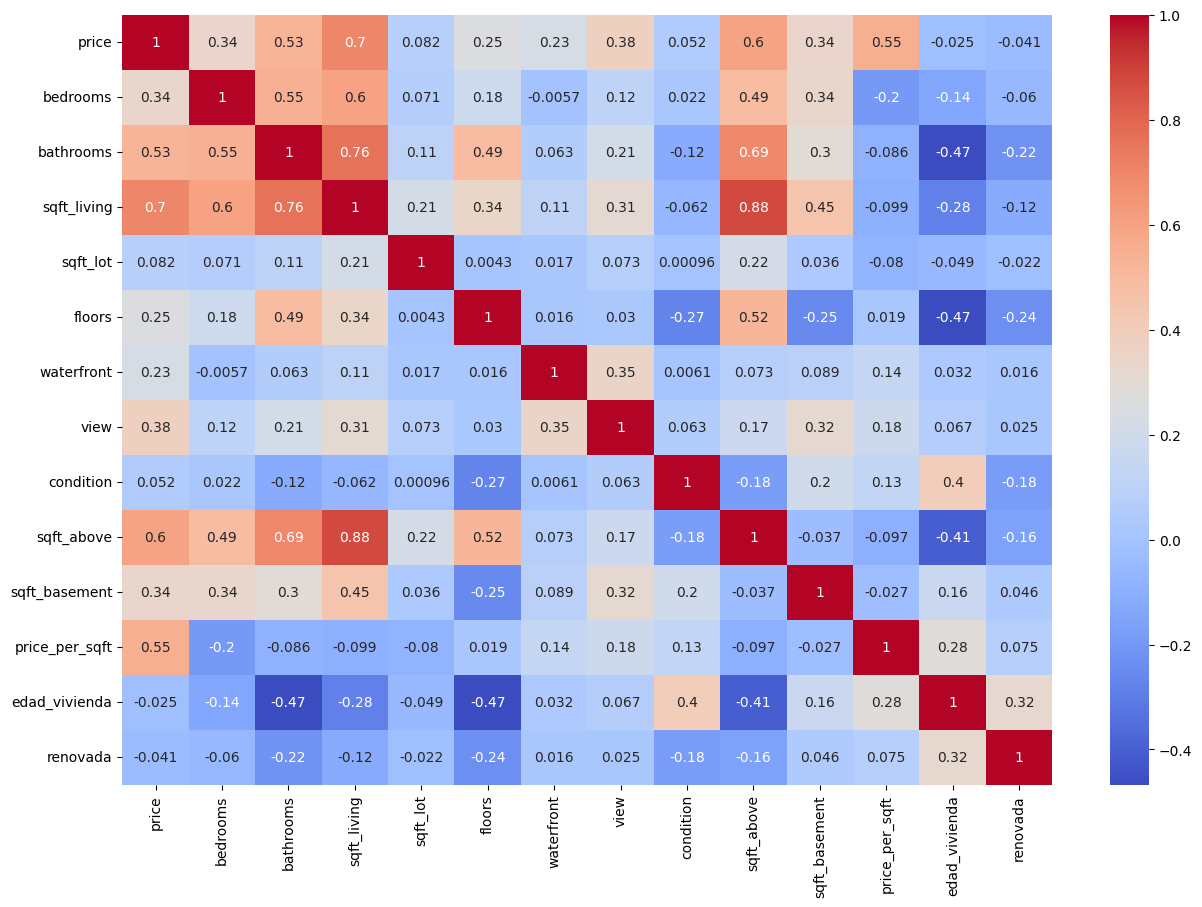

In [46]:
plt.figure(figsize=(15,10))
sns.heatmap(df_limpio2_corr, annot=True, cmap='coolwarm')

# **Modelado**

In [47]:
#se analiza las variables y el tipo de dato que son
df_limpio2.dtypes

,0
date,datetime64[ns]
price,float64
bedrooms,float64
bathrooms,float64
sqft_living,int64
sqft_lot,int64
floors,float64
waterfront,category
view,category
condition,category


In [48]:
# analizo la variable city que sería la única variable tipo object que considero para trabajar en el modelo
df_limpio2['city'].value_counts()

,count
city,
Seattle,1559
Renton,291
Bellevue,281
Redmond,234
Kirkland,187
Issaquah,186
Kent,183
Auburn,175
Sammamish,171


In [49]:
#Separo las variables predictoras que usaré con la variable objetivo
col_model = ['bedrooms',	'bathrooms', 'sqft_living',	'floors',	'waterfront',	'view',	'condition',	'edad_vivienda',	'renovada', 'city']

X = df_limpio2[col_model]
y = df_limpio2['price']

* *price_per_sqft* se descarta porque es una derivación directa de la variable objetivo. Incluirla causaría una fuga de datos (data leakage).

* *sqft_above* y *sqft_basement* se descartan porque son componentes de *sqft_living* (*sqft_living = sqft_above + sqft_basement*). Incluirlas introduciría multicolinealidad.

* *sqft_lot* se descarta porque el tamaño del terreno por sí solo no es un predictor significativo del precio de la vivienda.

* *street y statezip* se descartan por su alta cardinalidad (demasiados valores únicos) y ser una redundancia de la variable *city*



In [50]:
#observo mis variables predictoras
X

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,edad_vivienda,renovada,city
0,3.0,1.50,1340,1.5,0,0,3,59,1,Shoreline
1,5.0,2.50,3650,2.0,0,4,5,93,0,Seattle
2,3.0,2.00,1930,1.0,0,0,4,48,0,Kent
3,3.0,2.25,2000,1.0,0,0,4,51,0,Bellevue
4,4.0,2.50,1940,1.0,0,0,4,38,1,Redmond
...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,1.0,0,0,4,60,1,Seattle
4596,3.0,2.50,1460,2.0,0,0,3,31,1,Bellevue
4597,3.0,2.50,3010,2.0,0,0,3,5,0,Renton
4598,4.0,2.00,2090,1.0,0,0,3,40,0,Seattle


In [51]:
# codifico la variable object
X = pd.get_dummies(X, columns=['city'], drop_first=True, dtype=int)
X.head()

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,edad_vivienda,renovada,city_Auburn,...,city_SeaTac,city_Seattle,city_Shoreline,city_Skykomish,city_Snoqualmie,city_Snoqualmie Pass,city_Tukwila,city_Vashon,city_Woodinville,city_Yarrow Point
0,3.0,1.50,1340,1.5,0,0,3,59,1,0,...,0,0,1,0,0,0,0,0,0,0
1,5.0,2.50,3650,2.0,0,4,5,93,0,0,...,0,1,0,0,0,0,0,0,0,0
2,3.0,2.00,1930,1.0,0,0,4,48,0,0,...,0,0,0,0,0,0,0,0,0,0
3,3.0,2.25,2000,1.0,0,0,4,51,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4.0,2.50,1940,1.0,0,0,4,38,1,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
#se divide en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### **Modelo de Regresión Lineal**

In [53]:
# Se crea el modelo
modelo_lr = LinearRegression()
#Se entrena el modelo
modelo_lr.fit(X_train, y_train)

LinearRegression()

In [54]:
#Se realiza la predicción
y_pred_lr = modelo_lr.predict(X_test)

#### **Modelo de Bosque Aleatorio (Random Forest)**

In [55]:
#se genera el modelo

modelo_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
#se entrena el modelo
modelo_rf.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, n_estimators=200, random_state=42)

In [56]:
#se genera la predicción

y_pred_rf = modelo_rf.predict(X_test)

#**Evaluación**

In [57]:
# Se genera un función para evaluar y comparar los modelos generados

def evaluar_modelo(y_real, y_pred):

    mae = mean_absolute_error(y_real, y_pred)
    mse = mean_squared_error(y_real, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_real, y_pred)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }


resultados = {
    'Linear Regression': evaluar_modelo(y_test, y_pred_lr),
    'Random Forest': evaluar_modelo(y_test, y_pred_rf)
}


# 4. Mostrar resultados en una tabla
df_resultados = pd.DataFrame(resultados).T

# Redondear para facilitar la lectura
df_resultados = df_resultados.round(3)

display(df_resultados)

,MAE,MSE,RMSE,R2
Linear Regression,131136.192,5.045062e+10,224612.164,0.662
Random Forest,131540.926,5.877559e+10,242436.776,0.606


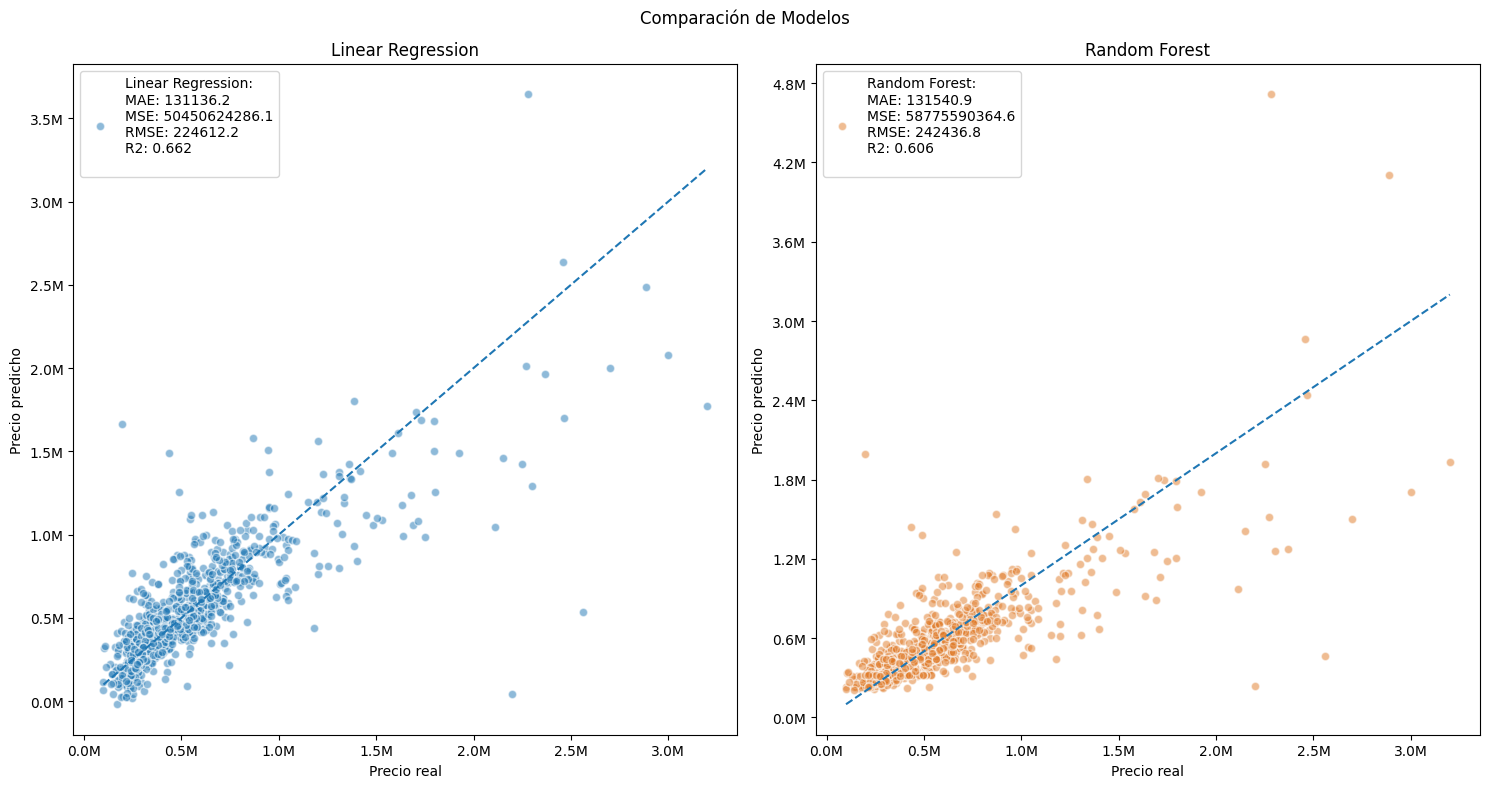

In [84]:
fig, ax = plt.subplots(1,2, figsize=(15,8))

fig.suptitle('Comparación de Modelos')

etiqueta_lr = (
    f'Linear Regression:\n'
    f'MAE: {df_resultados.iloc[0,0]:.1f}\n'
    f'MSE: {df_resultados.iloc[0,1]:.1f}\n'
    f'RMSE: {df_resultados.iloc[0,2]:.1f}\n'
    f'R2: {df_resultados.iloc[0,3]:.3f}\n'
)
ax[0].scatter(y_test, y_pred_lr, alpha=0.5, label=etiqueta_lr,  edgecolors='white')
ax[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
ax[0].set_xlabel('Precio real')
ax[0].set_ylabel('Precio predicho')
ax[0].set_title('Linear Regression')
ax[0].legend()
ax[0].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
ax[0].xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
ax[0].yaxis.set_major_locator(MaxNLocator(nbins=10))

etiqueta_rf = (
    f'Random Forest:\n'
    f'MAE: {df_resultados.iloc[1,0]:.1f}\n'
    f'MSE: {df_resultados.iloc[1,1]:.1f}\n'
    f'RMSE: {df_resultados.iloc[1,2]:.1f}\n'
    f'R2: {df_resultados.iloc[1,3]:.3f}\n'
)
ax[1].scatter(y_test, y_pred_rf, alpha=0.5, label=etiqueta_rf, color='#E07A27',
    edgecolors='white')
ax[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle='--')
ax[1].set_xlabel('Precio real')
ax[1].set_ylabel('Precio predicho')
ax[1].set_title('Random Forest')
ax[1].legend()
ax[1].yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
ax[1].xaxis.set_major_formatter(FuncFormatter(lambda y, pos: f'{y/1e6:.1f}M'))
ax[1].yaxis.set_major_locator(MaxNLocator(nbins=10))

plt.tight_layout()
plt.show()

**Análisis de Resultados de la evaluación del modelo**

* Ambos modelos presentan resultados similiares en las métricas de evaluación, con errores cercanos a $130000 en el MAE y 230000 en el MSE y un R2 cercano al 60%. El modelo de Regresión Lineal presenta un desempeño global ligeramente más favorable que Random Forest en el conjunto de prueba evaluado.
* Se identifican observaciones con errores de predicción elevados, tanto por sobreestimación como por subestimación, donde el error es mayor en viviendas de alto valor.
* La concentración de observaciones en rangos bajos y medios de precios implica que las métricas globales pueden no representar adecuadamente el desempeño en viviendas de alto valor.

**Conclusiones finales**

* El error presentado en ambos modelos es considerable considerando la media de $460000 del precio de las viviendas. Se entiende que esto puede estar influenciado por la base de datos en sí, como por la falta de algunos otros factores que un tasador consideraría importante, la falta de datos en categorias de variables predictoras importantes, o la notable presencia de valores atípicos.
